In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 500

data = pd.DataFrame({
    "age": np.random.normal(loc=60, scale=10, size=n).astype(int),
    "sex": np.random.choice(["M", "F"], size=n),
    "has_diabetes": np.random.choice([0, 1], p=[0.7, 0.3], size=n),
    "systolic_bp": np.random.normal(loc=140, scale=20, size=n),
})

print(data.head())
print(data.describe(include="all"))

   age sex  has_diabetes  systolic_bp
0   64   F             0   160.605669
1   58   F             0   144.775783
2   66   F             0   134.819157
3   75   M             0   136.073003
4   57   F             0   138.567975
               age  sex  has_diabetes  systolic_bp
count   500.000000  500    500.000000   500.000000
unique         NaN    2           NaN          NaN
top            NaN    M           NaN          NaN
freq           NaN  260           NaN          NaN
mean     59.540000  NaN      0.316000   141.391120
std       9.831262  NaN      0.465379    20.268494
min      27.000000  NaN      0.000000    82.074892
25%      52.750000  NaN      0.000000   127.100839
50%      60.000000  NaN      0.000000   141.136630
75%      66.000000  NaN      1.000000   154.577644
max      98.000000  NaN      1.000000   192.033662


In [2]:
from ctgan import CTGAN

discrete_cols = ["sex", "has_diabetes"]
ctgan = CTGAN(epochs=10)
ctgan.fit(data, discrete_cols)
synthetic = ctgan.sample(500)
print(synthetic.head())
print(synthetic.describe(include="all"))


  File "c:\Users\tun\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\tun\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\tun\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\tun\anaconda3\Lib\subprocess.py", lin

   age sex  has_diabetes  systolic_bp
0   59   M             0   152.726390
1   57   M             0   174.839460
2   80   F             0   101.814930
3   70   F             1    87.230650
4   51   F             1   121.554681
               age  sex  has_diabetes  systolic_bp
count   500.000000  500    500.000000   500.000000
unique         NaN    2           NaN          NaN
top            NaN    F           NaN          NaN
freq           NaN  266           NaN          NaN
mean     57.116000  NaN      0.472000   129.098855
std      12.957559  NaN      0.499715    25.444724
min      28.000000  NaN      0.000000    66.714207
25%      48.000000  NaN      0.000000   109.825187
50%      57.000000  NaN      0.000000   129.308926
75%      65.000000  NaN      1.000000   146.303830
max      98.000000  NaN      1.000000   203.669430


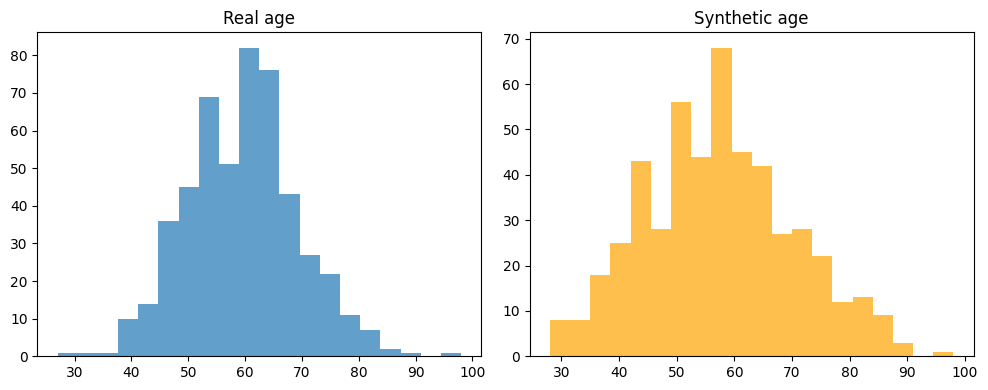

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(data["age"], bins=20, alpha=0.7, label="real")
axes[0].set_title("Real age")
axes[1].hist(synthetic["age"], bins=20, alpha=0.7, color="orange", label="synthetic")
axes[1].set_title("Synthetic age")
plt.tight_layout()
plt.show()

In [4]:
print("Real diabetes rate:", data["has_diabetes"].mean())
print("Synthetic diabetes rate:", synthetic["has_diabetes"].mean())

Real diabetes rate: 0.316
Synthetic diabetes rate: 0.472
